In [39]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

In [40]:
df = pd.read_csv('/kaggle/input/datasets/pragatigupta25/tweets/Tweets (1).csv')

print(df.head())

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  


In [41]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    return text.lower()

df['clean_text'] = df['text'].astype(str).apply(clean_text)

In [42]:
texts = df['clean_text'].tolist()

label_map = {
    'positive': 1,
    'negative': 0,
    'neutral': 2
}

labels = df['sentiment'].map(label_map).tolist()

In [43]:
df = df.sample(200)

In [44]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

encodings = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

Dataset Class

In [45]:
class SimpleDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

dataset = SimpleDataset(encodings, labels)
loader = DataLoader(dataset, batch_size=2)

Load Model (with Attention Output)

In [46]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,   # changed from 2 → 3
    output_attentions=True
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning

In [47]:
for epoch in range(2):
    total_loss = 0
    steps = 0

    for i, batch in enumerate(loader):
        if i == 50:  # limit for speed
            break

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        steps += 1

    avg_loss = total_loss / steps
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

Epoch 1, Avg Loss: 1.1580
Epoch 2, Avg Loss: 1.1580


Extract Attention Weights

In [51]:
model.eval()

inputs = tokenizer("I love this product", return_tensors="pt")
outputs = model(**inputs)

attentions = outputs.attentions  # tuple of layers

Visualize Attention Heatmap

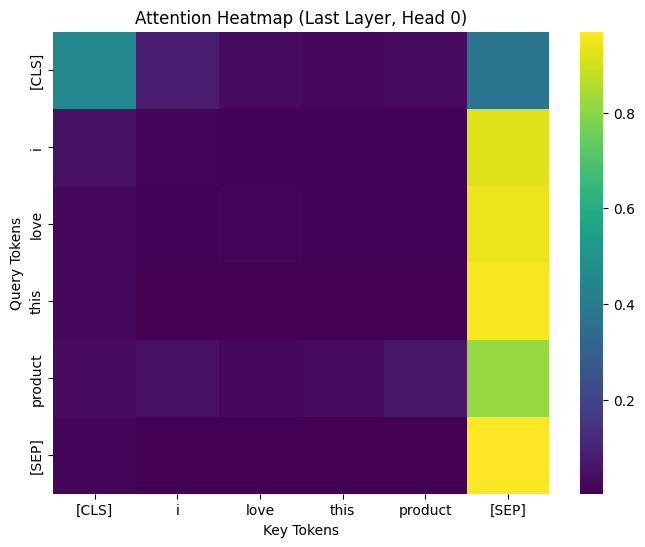

In [49]:
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

attention = attentions[-1][0][0].detach().numpy()  # last layer, head 0

plt.figure(figsize=(8,6))
sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
plt.title("Attention Heatmap (Last Layer, Head 0)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()